In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [26]:
train_dir = "/kaggle/input/datasets/shreyashkumarsah/processed-corn-7/processed_corn_7/train"
val_dir = "/kaggle/input/datasets/shreyashkumarsah/processed-corn-7/processed_corn_7/val"
test_dir = "/kaggle/input/datasets/shreyashkumarsah/processed-corn-7/processed_corn_7/test"

In [27]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [28]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.2,

    width_shift_range=0.1,
    height_shift_range=0.1,

    shear_range=0.1,

    brightness_range=[0.8, 1.3],

    horizontal_flip=True,

    fill_mode='nearest'
)

In [29]:
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [30]:
#train loader
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 3732 images belonging to 4 classes.


In [31]:
#validation loader
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 698 images belonging to 4 classes.


In [32]:
#test loader
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 236 images belonging to 4 classes.


In [33]:
print(train_generator.class_indices)

{'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}


In [34]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 4)


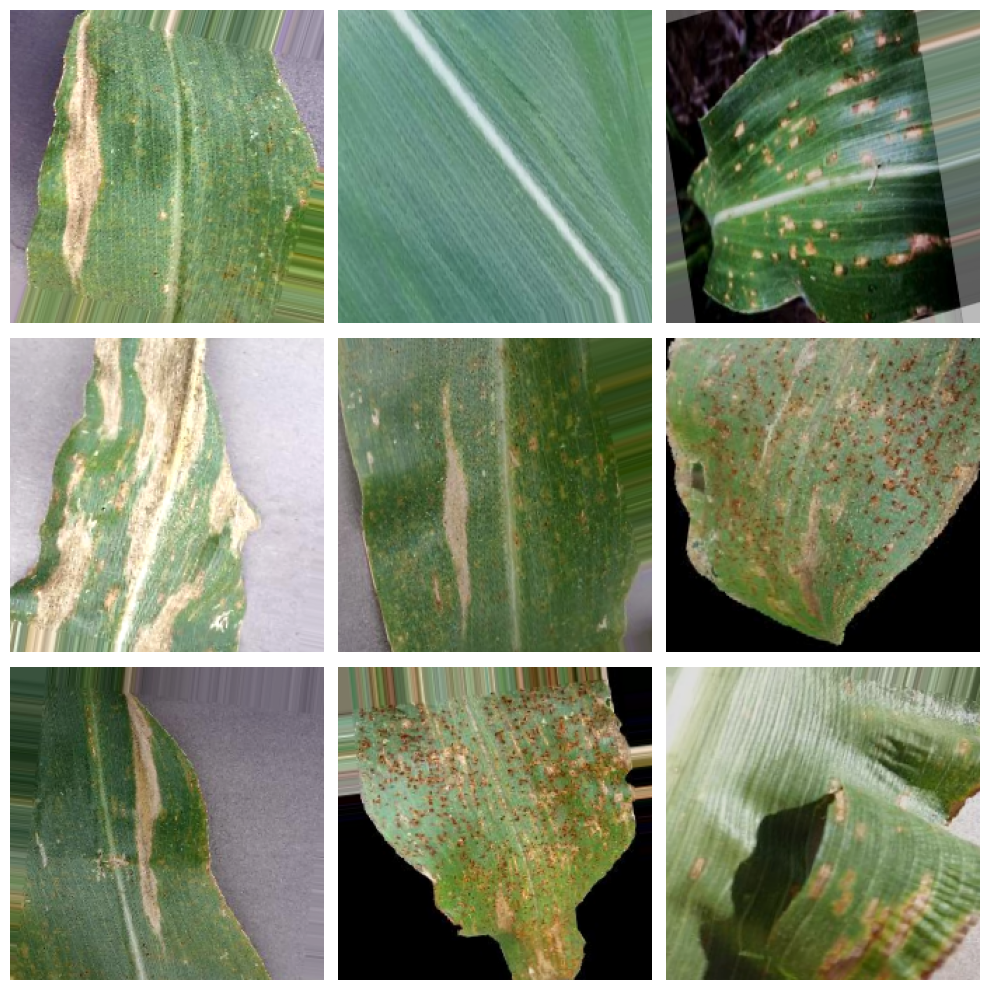

In [35]:
#Augmented Image Visualisation
import matplotlib.pyplot as plt

# Ek batch lo
images, labels = next(train_generator)

# 9 images show karo
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D

model = Sequential([

    Conv2D(32, (3,3), activation='relu',padding="same", input_shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu',padding="same"),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu',padding="same"),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu',padding="same"),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu',padding="same"),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.35),

    Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,65

 Total params: 4,980,900 (19.00 MB)

 Trainable params: 4,978,916 (18.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

In [40]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
)

Epoch 1/40
 44/117 ━━━━━━━━━━━━━━━━━━━━ 44s 613ms/step - accuracy: 0.5057 - loss: 1.4638

2026-07-09 10:32:54.594801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 10:32:54.746841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 10:32:55.472418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 10:32:55.618507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 10:32:57.079823: E external/local_xla/xla/stream_

117/117 ━━━━━━━━━━━━━━━━━━━━ 108s 833ms/step - accuracy: 0.7069 - loss: 0.7778 - val_accuracy: 0.2937 - val_loss: 1.8767 - learning_rate: 0.0010
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 61s 518ms/step - accuracy: 0.8017 - loss: 0.5206 - val_accuracy: 0.2607 - val_loss: 3.6692 - learning_rate: 0.0010
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 511ms/step - accuracy: 0.8304 - loss: 0.4223 - val_accuracy: 0.3037 - val_loss: 1.6274 - learning_rate: 0.0010
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 61s 521ms/step - accuracy: 0.8481 - loss: 0.3954 - val_accuracy: 0.3610 - val_loss: 1.3603 - learning_rate: 0.0010
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 506ms/step - accuracy: 0.8465 - loss: 0.3976 - val_accuracy: 0.7894 - val_loss: 0.6542 - learning_rate: 0.0010
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 506ms/step - accuracy: 0.8518 - loss: 0.3691 - val_accuracy: 0.8481 - val_loss: 0.3806 - learning_rate: 0.0010
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 514ms/step - accuracy: 0.8553 - loss

In [41]:
model.save("/kaggle/working/corn_model_11.keras")

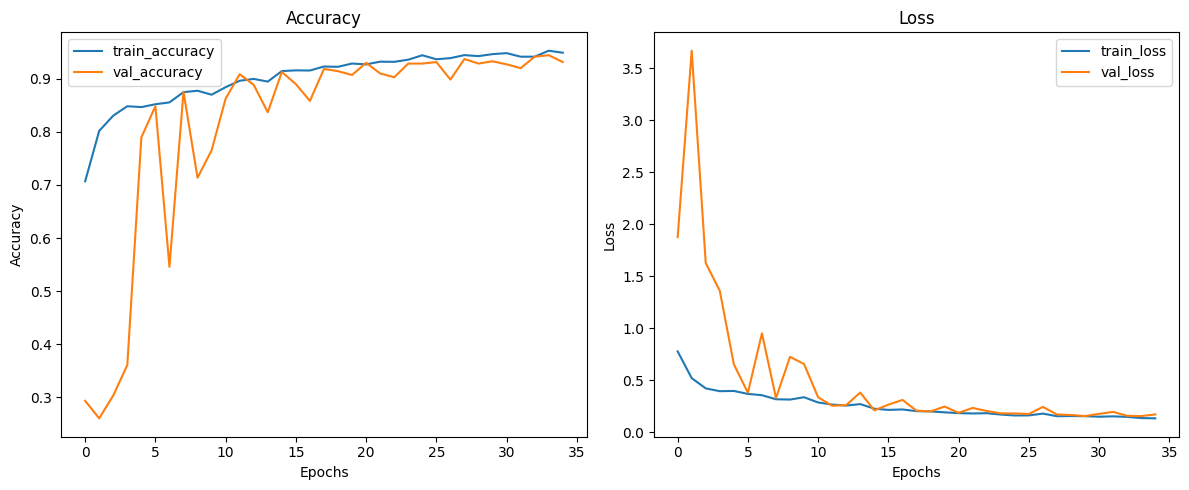

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.9068 - loss: 0.2239
Test Loss : 0.22390398383140564
Test Accuracy : 0.9067796468734741


In [44]:
import numpy as np

Y_pred = model.predict(test_generator)

y_pred = np.argmax(Y_pred, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step


In [45]:
y_true = test_generator.classes
print(y_true)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [46]:
class_names = list(test_generator.class_indices.keys())

print(class_names)

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

        Blight       0.80      0.92      0.86        62
   Common_Rust       0.94      0.96      0.95        69
Gray_Leaf_Spot       0.91      0.70      0.79        44
       Healthy       0.98      0.98      0.98        61

      accuracy                           0.91       236
     macro avg       0.91      0.89      0.90       236
  weighted avg       0.91      0.91      0.91       236



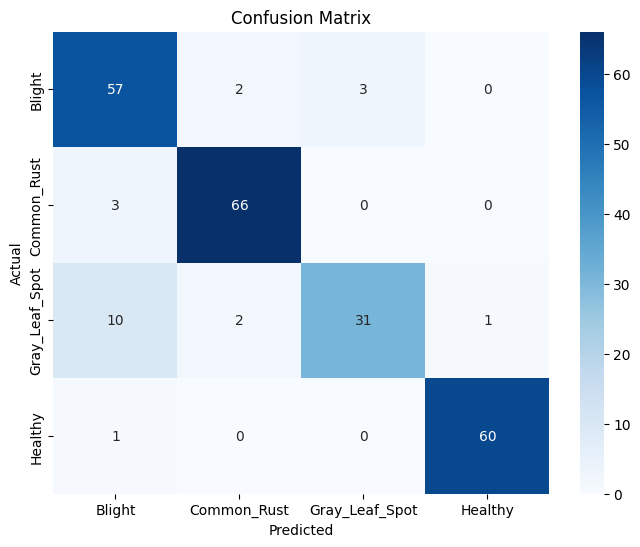

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()